# EDA 및 이상치 분석

**입력**: `02_데이터_조인.ipynb` 출력 → `../데이터셋/starbucks_merged.csv`  
**목적**: 통합 데이터 기초 탐색, `amount`(거래 금액) 분포·이상치 분석(Quantile, Z-Score, IQR)

## 실행 순서
파이프라인: `00_데이터_확인` → `01_데이터_전처리` → `02_데이터_조인` → **03_EDA_이상치_분석**

## 1. 라이브러리 및 데이터 불러오기

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# starbucks_merged 경로: ../데이터셋 우선, 없으면 ../data/전처리_완료_데이터셋
CLEAN_DIR = "../데이터셋" if os.path.isdir("../데이터셋") else "../data/전처리_완료_데이터셋"
df = pd.read_csv(os.path.join(CLEAN_DIR, "starbucks_merged.csv"), encoding='utf-8-sig')
print(f"Shape: {df.shape}")
print(f"컬럼: {df.columns.tolist()}")

Shape: (306066, 26)
컬럼: ['Unnamed: 0', 'customer_id', 'event', 'value', 'time', 'offer_id', 'amount', 'Unnamed: 0_profile', 'gender', 'age', 'became_member_on', 'income', 'Unnamed: 0_portfolio', 'reward', 'channels', 'difficulty', 'duration', 'offer_type', 'channels_parsed', 'channel_email', 'channel_mobile', 'channel_social', 'channel_web', 'member_year', 'member_month', 'member_year_month']


## 2. 기초 EDA

In [2]:
print("=== 결측치 ===")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\n=== 이벤트별 건수 ===")
print(df['event'].value_counts())

=== 결측치 ===
offer_id                138485
amount                  167581
gender                   33762
income                   33762
Unnamed: 0_portfolio    138485
reward                  138485
channels                138485
difficulty              138485
duration                138485
offer_type              138485
channels_parsed         138485
channel_email           138485
channel_mobile          138485
channel_social          138485
channel_web             138485
dtype: int64

=== 이벤트별 건수 ===
event
transaction        138485
offer received      76277
offer viewed        57725
offer completed     33579
Name: count, dtype: int64


In [3]:
# amount는 'transaction' 이벤트에만 존재
df_amount = df[df['amount'].notna()].copy()
values = df_amount['amount']
print(f"amount 비결측 행 수: {len(df_amount):,}")
print(values.describe())

amount 비결측 행 수: 138,485
count    138485.000000
mean         11.328511
std           9.949725
min           0.050000
25%           2.770000
50%           8.830000
75%          17.960000
max         103.280000
Name: amount, dtype: float64


## 3. amount 분포 시각화

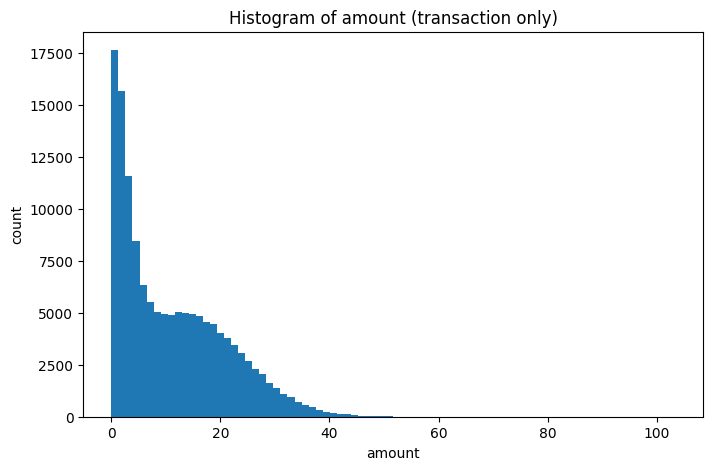

In [4]:
plt.figure(figsize=(8, 5))
plt.hist(values, bins=80)
plt.xlabel('amount')
plt.ylabel('count')
plt.title('Histogram of amount (transaction only)')
plt.show()

## 4. Quantile 기반 이상치

In [5]:
LOW_Q = 0.001   # 하위 0.1%
HIGH_Q = 0.999  # 상위 99.9%

low_thr = values.quantile(LOW_Q)
high_thr = values.quantile(HIGH_Q)
print(f"Quantile 기준: 하한 {low_thr:.2f}, 상한 {high_thr:.2f}")

amount_outlier_q = (values <= low_thr) | (values >= high_thr)
n_outlier_q = amount_outlier_q.sum()
print(f"Quantile 기준 이상치 건수: {n_outlier_q:,} ({100 * n_outlier_q / len(values):.4f}%)")

Quantile 기준: 하한 0.05, 상한 66.64
Quantile 기준 이상치 건수: 570 (0.4116%)


## 5. Z-Score 기반 이상치

In [6]:
zscore_arr = StandardScaler().fit_transform(df_amount[['amount']])
df_amount = df_amount.copy()
df_amount['zscore'] = zscore_arr

# |z| > 3 을 이상치로
mask_z = (df_amount['zscore'] < -3) | (df_amount['zscore'] > 3)
strange_df = df_amount[mask_z][['amount', 'zscore']]
print(f"Z-Score(±3) 기준 이상치 건수: {len(strange_df):,}")
strange_df.head(10)

Z-Score(±3) 기준 이상치 건수: 742


,amount,zscore
13751,45.09,3.393221
15148,44.27,3.310806
15520,43.26,3.209295
16148,42.36,3.118840
16347,44.54,3.337943
16680,43.42,3.225376
16919,41.58,3.040446
17040,44.14,3.297740
17330,92.36,8.144123
17332,41.83,3.065572


## 6. IQR 기반 이상치

In [7]:
Q1 = values.quantile(0.25)
Q3 = values.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("=== IQR 기반 이상치 ===")
print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"하한: {lower_bound:.2f}, 상한: {upper_bound:.2f}")

out_lower = (values < lower_bound).sum()
out_upper = (values > upper_bound).sum()
print(f"IQR 기준 하한 이상치: {out_lower:,}, 상한 이상치: {out_upper:,}")

=== IQR 기반 이상치 ===
Q1: 2.77, Q3: 17.96, IQR: 15.19
하한: -20.02, 상한: 40.75
IQR 기준 하한 이상치: 0, 상한 이상치: 792


## 7. 박스플롯 (Z-Score 이상치 강조)

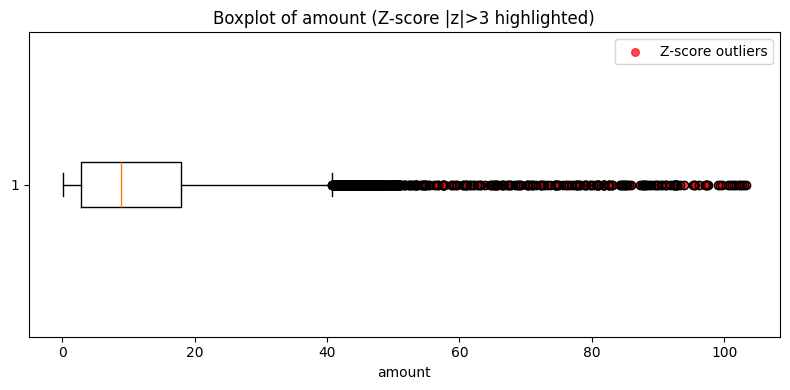

In [8]:
plt.figure(figsize=(8, 4))
plt.boxplot(values, vert=False)
if len(strange_df) > 0:
    plt.scatter(strange_df['amount'], [1] * len(strange_df), color='red', alpha=0.7, s=30, label='Z-score outliers')
plt.xlabel('amount')
plt.title('Boxplot of amount (Z-score |z|>3 highlighted)')
plt.legend()
plt.tight_layout()
plt.show()

## 8. 요약

In [9]:
summary = pd.DataFrame({
    '방법': ['Quantile(0.1%, 99.9%)', 'Z-Score(±3)', 'IQR(1.5×IQR)'],
    '이상치_건수': [n_outlier_q, len(strange_df), out_lower + out_upper]
})
summary['비율(%)'] = (summary['이상치_건수'] / len(values) * 100).round(4)
print("=== 이상치 요약 ===")
print(summary.to_string(index=False))

=== 이상치 요약 ===
                   방법  이상치_건수  비율(%)
Quantile(0.1%, 99.9%)     570 0.4116
          Z-Score(±3)     742 0.5358
         IQR(1.5×IQR)     792 0.5719
